In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel('USA_Housing_Dataset.xlsx')  # sesuaikan path file lu
print("Shape awal:", df.shape)

# 1. Drop baris dengan price == 0 (harga gak valid)
df = df[df['price'] > 0].copy()
print("Setelah drop price==0:", df.shape)

# 2. Drop outlier ekstrem yang gak masuk akal (data corrupt, misal ada harga 950 milyar USD)
df = df[df['price'] <= 5_000_000].copy()
print("Setelah drop harga > 5 juta:", df.shape)

# 3. Drop harga yang terlalu rendah buat masuk akal jadi rumah beneran
df = df[df['price'] >= 50_000].copy()
print("Setelah drop harga < 50rb:", df.shape)

# 4. Drop kolom 'country' -> cuma 1 nilai unik, gak informatif
df = df.drop(columns=['country'])

# Cek hasil akhir
print("\nShape final:", df.shape)
print(df['price'].describe())

# Cek duplikat
print("\nJumlah duplikat:", df.duplicated().sum())

# Simpan hasil cleaning (opsional, biar gak ngulang tiap buka notebook)
df.to_csv('house_clean.csv', index=False)

Shape awal: (4140, 18)
Setelah drop price==0: (4091, 18)
Setelah drop harga > 5 juta: (4002, 18)
Setelah drop harga < 50rb: (4001, 18)

Shape final: (4001, 17)
count    4.001000e+03
mean     5.518716e+05
std      3.578638e+05
min      8.000000e+04
25%      3.299000e+05
50%      4.652500e+05
75%      6.610000e+05
max      4.668000e+06
Name: price, dtype: float64

Jumlah duplikat: 0


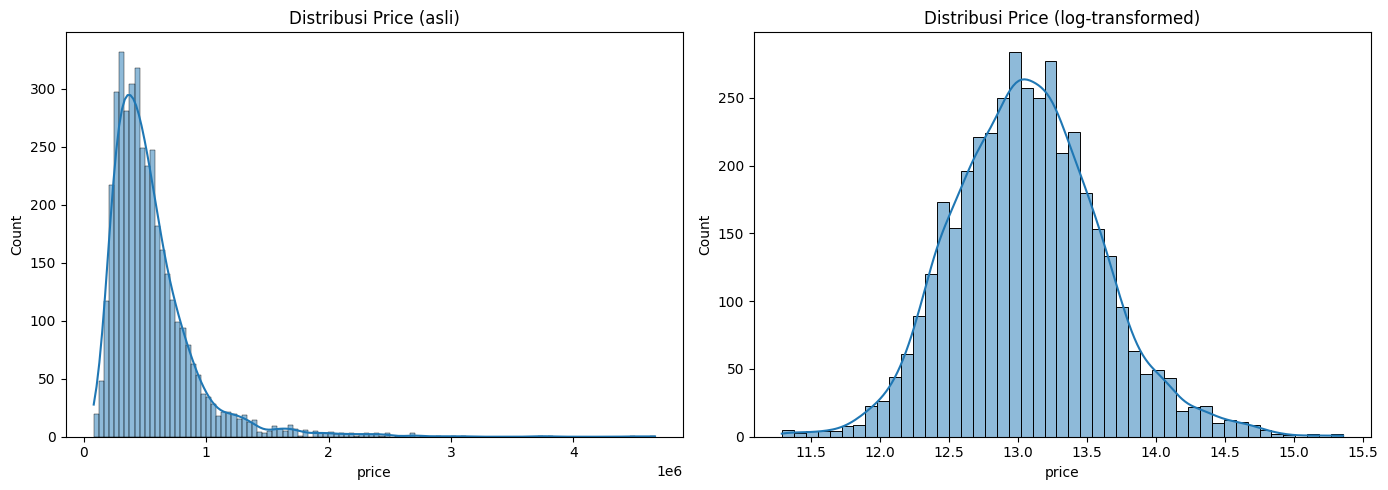

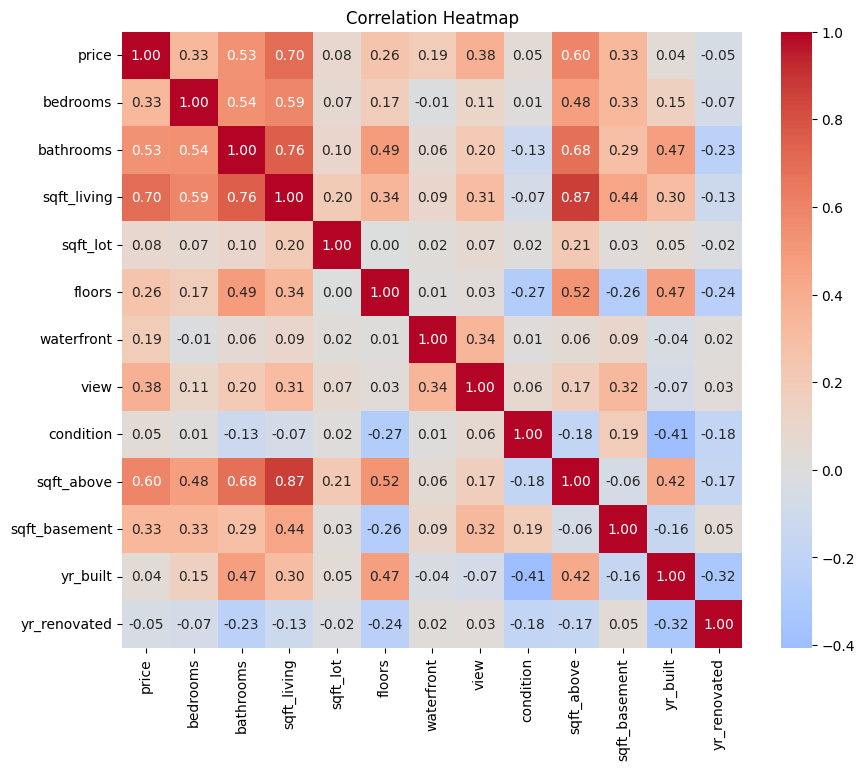

price            1.000000
sqft_living      0.701479
sqft_above       0.597650
bathrooms        0.531577
view             0.380878
sqft_basement    0.334253
bedrooms         0.330210
floors           0.256632
waterfront       0.192409
sqft_lot         0.081988
condition        0.047474
yr_built         0.039394
yr_renovated    -0.047602
Name: price, dtype: float64


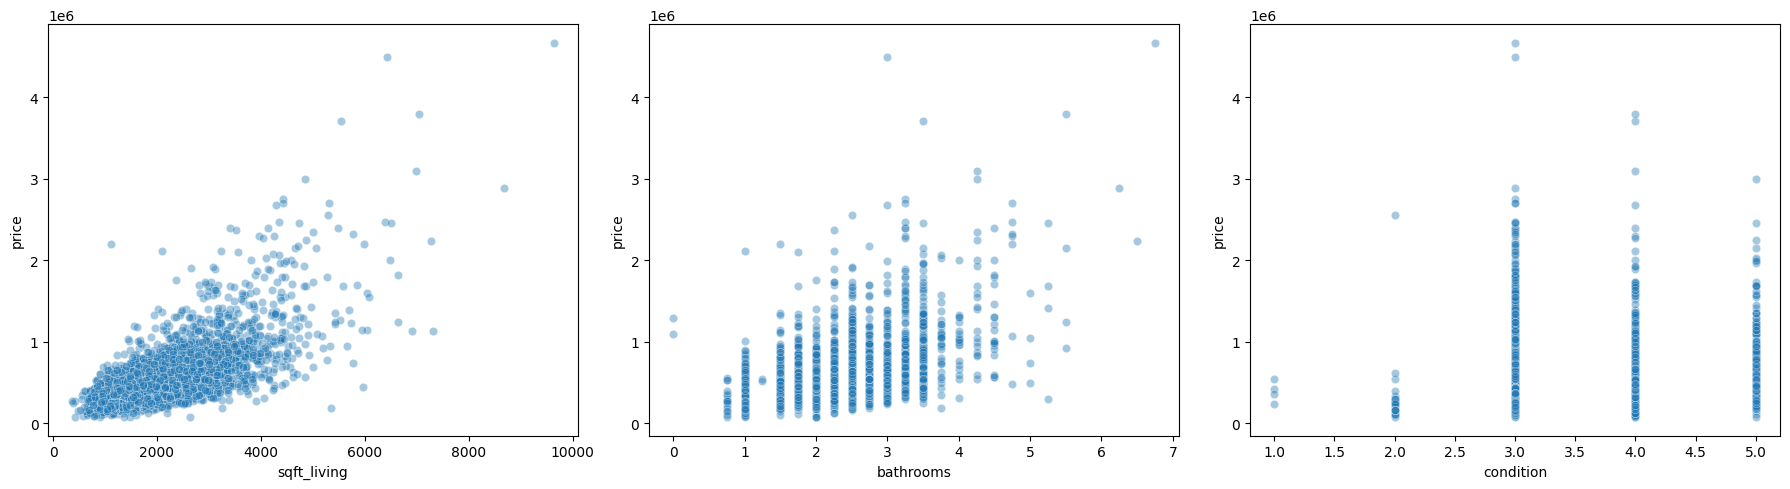

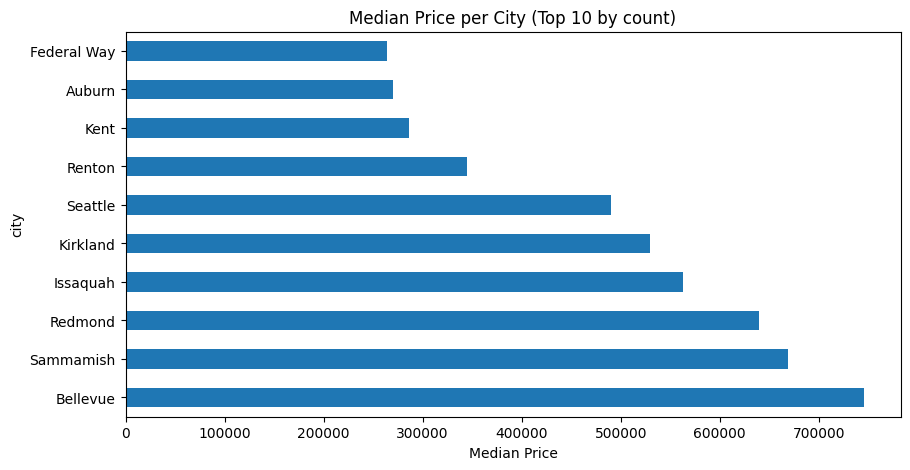

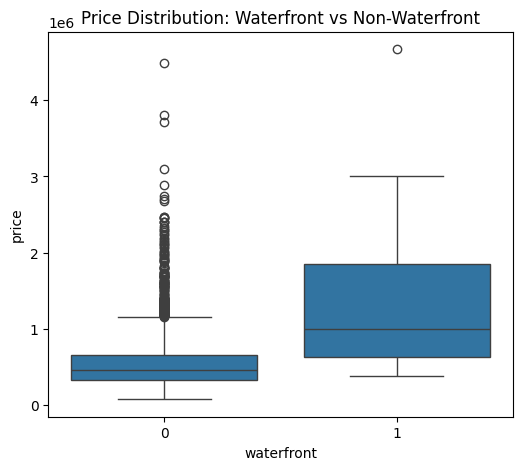

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load hasil cleaning
df = pd.read_csv('house_clean.csv')

# 1. Distribusi target (price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Price (asli)')

sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1])
axes[1].set_title('Distribusi Price (log-transformed)')
plt.tight_layout()
plt.show()

# 2. Korelasi fitur numerik ke price
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                 'floors', 'waterfront', 'view', 'condition', 'sqft_above',
                 'sqft_basement', 'yr_built', 'yr_renovated']

corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# 3. Cek fitur yang paling berkorelasi sama price
print(corr['price'].sort_values(ascending=False))

# 4. Scatter plot fitur paling berpengaruh vs price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='sqft_living', y='price', data=df, ax=axes[0], alpha=0.4)
sns.scatterplot(x='bathrooms', y='price', data=df, ax=axes[1], alpha=0.4)
sns.scatterplot(x='grade' if 'grade' in df.columns else 'condition', y='price', data=df, ax=axes[2], alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Harga rata-rata per kota (top 10 kota dengan data terbanyak)
top_cities = df['city'].value_counts().head(10).index
city_price = df[df['city'].isin(top_cities)].groupby('city')['price'].median().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
city_price.plot(kind='barh')
plt.title('Median Price per City (Top 10 by count)')
plt.xlabel('Median Price')
plt.show()

# 6. Boxplot price vs waterfront (rumah tepi air biasanya jauh lebih mahal)
plt.figure(figsize=(6, 5))
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Price Distribution: Waterfront vs Non-Waterfront')
plt.show()

In [3]:
# 1. Handle multicollinearity: sqft_above sangat redundant dgn sqft_living
#    Opsi: drop sqft_above, karena sqft_living udah mencakup infonya
df_fe = df.drop(columns=['sqft_above'])

# 2. Bikin fitur umur rumah (lebih informatif daripada yr_built mentah)
df_fe['house_age'] = 2014 - df_fe['yr_built']   # dataset tahun 2014, sesuaikan kalau beda

# 3. Ubah yr_renovated jadi fitur biner + fitur "tahun sejak renovasi terakhir"
df_fe['is_renovated'] = (df_fe['yr_renovated'] > 0).astype(int)
df_fe['years_since_renovation'] = np.where(
    df_fe['is_renovated'] == 1,
    2014 - df_fe['yr_renovated'],
    df_fe['house_age']  # kalau belum direnovasi, anggap sama dgn umur rumah
)

# 4. Drop kolom mentah yang udah digantikan fitur turunannya
df_fe = df_fe.drop(columns=['yr_built', 'yr_renovated'])

# 5. Handle high-cardinality categorical: city & statezip
#    street didrop karena hampir unique per baris (gak generalizable)
df_fe = df_fe.drop(columns=['street', 'date'])

print("Jumlah kota unik:", df_fe['city'].nunique())
print(df_fe['city'].value_counts())

# Karena city cukup banyak, encode pake target encoding atau frequency encoding
# (opsi simpel: frequency encoding dulu)
city_freq = df_fe['city'].value_counts(normalize=True)
df_fe['city_freq'] = df_fe['city'].map(city_freq)

# statezip -> ekstrak cuma kode zip-nya
df_fe['zip'] = df_fe['statezip'].str.extract(r'(\d+)').astype(int)

df_fe = df_fe.drop(columns=['city', 'statezip'])

print("\nShape setelah feature engineering:", df_fe.shape)
print(df_fe.columns.tolist())
print(df_fe.head())

df_fe.to_csv('house_features.csv', index=False)

Jumlah kota unik: 43
city
Seattle               1375
Renton                 250
Bellevue               250
Redmond                203
Kirkland               163
Issaquah               160
Auburn                 157
Kent                   156
Sammamish              147
Federal Way            125
Shoreline              110
Woodinville            102
Maple Valley            88
Mercer Island           76
Snoqualmie              63
Burien                  60
Kenmore                 55
Des Moines              51
North Bend              44
Duvall                  38
Covington               37
Lake Forest Park        31
Newcastle               31
Bothell                 30
SeaTac                  28
Vashon                  28
Tukwila                 27
Enumclaw                26
Carnation               18
Normandy Park           15
Medina                  11
Fall City                9
Clyde Hill               8
Black Diamond            6
Pacific                  6
Yarrow Point             4
Ra

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

df_fe = pd.read_csv('house_features.csv')

# Random Forest itu tree-based, jadi:
# - gak butuh scaling
# - gak butuh log-transform target (tapi tetep boleh, kita coba tanpa dulu biar simpel)
X = df_fe.drop(columns=['price', 'zip'])
y = df_fe['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model baseline - pake parameter default dulu, belum tuning apa-apa
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prediksi
y_pred = rf.predict(X_test)

# Evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : ${rmse:,.0f}")
print(f"MAE  : ${mae:,.0f}")
print(f"R2   : {r2:.4f}")

# Feature importance - biar keliatan fitur apa yang paling dipake model
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df.to_string(index=False))

RMSE : $202,997
MAE  : $125,047
R2   : 0.5115

Feature Importance:
               feature  importance
           sqft_living    0.575551
             city_freq    0.098431
              sqft_lot    0.072645
             house_age    0.061054
         sqft_basement    0.037535
             bathrooms    0.036048
years_since_renovation    0.033059
                  view    0.029884
              bedrooms    0.018353
                floors    0.011966
             condition    0.010558
            waterfront    0.010407
          is_renovated    0.004507


In [5]:
from sklearn.model_selection import train_test_split, KFold
import numpy as np

df_fe = pd.read_csv('house_features.csv')

# Target encoding city (pakai K-Fold biar gak data leakage)
X_full = df_fe.drop(columns=['price', 'zip', 'city_freq'])
y_full = df_fe['price']

# Perlu kolom city asli buat target encoding, jadi kita re-load dari cleaned data
df_clean = pd.read_csv('house_clean.csv')
X_full['city'] = df_clean.loc[df_fe.index, 'city'].values

def target_encode_kfold(df, col, target, n_splits=5, seed=42):
    encoded = pd.Series(index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = target.mean()

    for train_idx, val_idx in kf.split(df):
        means = target.iloc[train_idx].groupby(df[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = df[col].iloc[val_idx].map(means)

    encoded = encoded.fillna(global_mean)
    return encoded

X_full['city_target_enc'] = target_encode_kfold(X_full, 'city', y_full)
X_full = X_full.drop(columns=['city'])

print(X_full.columns.tolist())
print(X_full[['city_target_enc']].describe())

X_full.to_csv('house_features_v2.csv', index=False)
y_full.to_csv('house_target_v2.csv', index=False)

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'house_age', 'is_renovated', 'years_since_renovation', 'city_target_enc']
       city_target_enc
count     4.001000e+03
mean      5.520583e+05
std       1.985672e+05
min       2.191333e+05
25%       3.794536e+05
50%       5.745432e+05
75%       6.113942e+05
max       2.397394e+06


In [7]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = pd.read_csv('house_features_v2.csv')
y = pd.read_csv('house_target_v2.csv').squeeze()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ruang parameter yang mau dicari
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,          # jumlah kombinasi yang dicoba (bukan grid penuh, biar cepet)
    cv=5,                # 5-fold cross validation
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

# Evaluasi model terbaik di test set
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE : ${rmse:,.0f}")
print(f"Test MAE  : ${mae:,.0f}")
print(f"Test R2   : {r2:.4f}")

# Feature importance versi model yang udah dituning
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance (tuned model):")
print(importance_df.to_string(index=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
Best CV R2: 0.7026528923952382

Test RMSE : $168,439
Test MAE  : $103,677
Test R2   : 0.6637

Feature Importance (tuned model):
               feature  importance
           sqft_living    0.576977
       city_target_enc    0.183367
              sqft_lot    0.049232
             house_age    0.045320
                  view    0.032625
         sqft_basement    0.029032
             bathrooms    0.024831
years_since_renovation    0.024308
              bedrooms    0.010324
            waterfront    0.007012
                floors    0.006897
             condition    0.006711
          is_renovated    0.003362


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_fe = pd.read_csv('house_features.csv')
df_clean = pd.read_csv('house_clean.csv')

X = df_fe.drop(columns=['price', 'city_freq'])
y = df_fe['price']
X['city'] = df_clean.loc[df_fe.index, 'city'].values

# Target encoding utk city (pakai fungsi yang sama kayak sebelumnya)
def target_encode_kfold(df, col, target, n_splits=5, seed=42):
    encoded = pd.Series(index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = target.mean()
    for train_idx, val_idx in kf.split(df):
        means = target.iloc[train_idx].groupby(df[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = df[col].iloc[val_idx].map(means)
    return encoded.fillna(global_mean)

X['city_target_enc'] = target_encode_kfold(X, 'city', y)

# Target encoding juga utk zip (lebih granular)
X['zip_target_enc'] = target_encode_kfold(X, 'zip', y)

X = X.drop(columns=['city', 'zip'])

# Feature interaction - kombinasi yang biasanya kepake di kasus housing
X['sqft_living_per_bathroom'] = X['sqft_living'] / (X['bathrooms'] + 1)  # +1 biar gak div by zero
X['lot_to_living_ratio'] = X['sqft_lot'] / X['sqft_living']
X['total_rooms'] = X['bedrooms'] + X['bathrooms']
X['bath_bed_ratio'] = X['bathrooms'] / (X['bedrooms'] + 1)

print("Fitur sekarang:", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=300, min_samples_split=2, min_samples_leaf=2,
    max_features=None, max_depth=None, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE : ${rmse:,.0f}")
print(f"MAE  : ${mae:,.0f}")
print(f"R2   : {r2:.4f}")

importance_df = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print(importance_df.to_string(index=False))

X.to_csv('house_features_v3.csv', index=False)

Fitur sekarang: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'house_age', 'is_renovated', 'years_since_renovation', 'city_target_enc', 'zip_target_enc', 'sqft_living_per_bathroom', 'lot_to_living_ratio', 'total_rooms', 'bath_bed_ratio']
RMSE : $138,756
MAE  : $85,329
R2   : 0.7718
                 feature  importance
             sqft_living    0.498553
          zip_target_enc    0.275080
                    view    0.034227
         city_target_enc    0.031550
                sqft_lot    0.019591
               house_age    0.018589
sqft_living_per_bathroom    0.017609
           sqft_basement    0.016351
  years_since_renovation    0.016143
          bath_bed_ratio    0.014099
     lot_to_living_ratio    0.013042
             total_rooms    0.011306
              waterfront    0.010907
               bathrooms    0.010874
                  floors    0.003546
               condition    0.003377
                bed

In [10]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

X = pd.read_csv('house_features_v3.csv')
y = df_fe['price']  # pastikan index/urutan sama kayak waktu bikin X

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [None, 15, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE : ${rmse:,.0f}")
print(f"Test MAE  : ${mae:,.0f}")
print(f"Test R2   : {r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}
Best CV R2: 0.7646210923073264

Test RMSE : $138,630
Test MAE  : $85,277
Test R2   : 0.7722


c:\Users\Personal\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


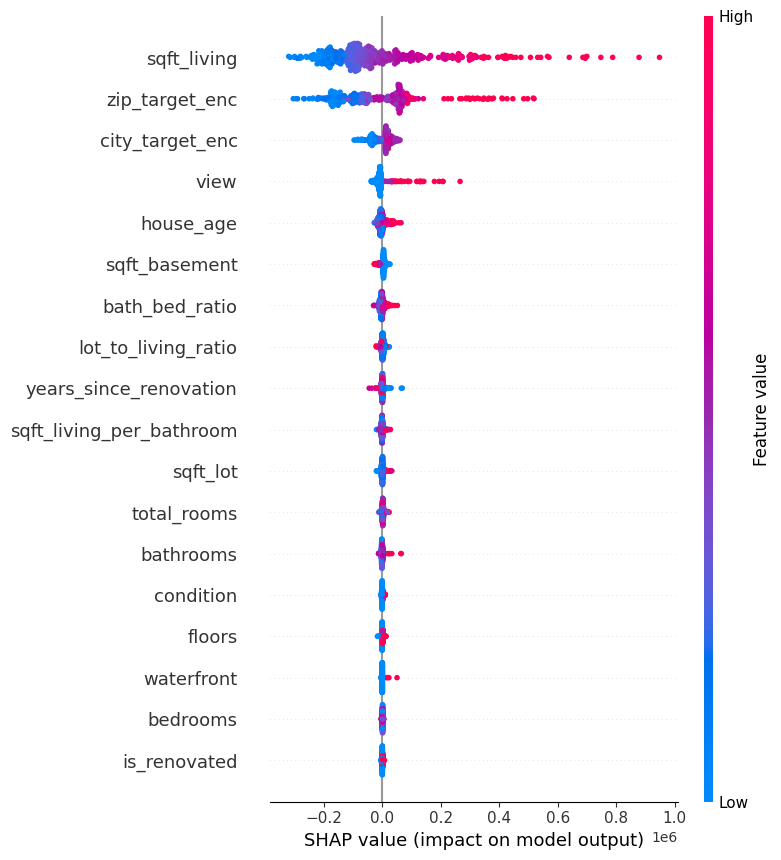

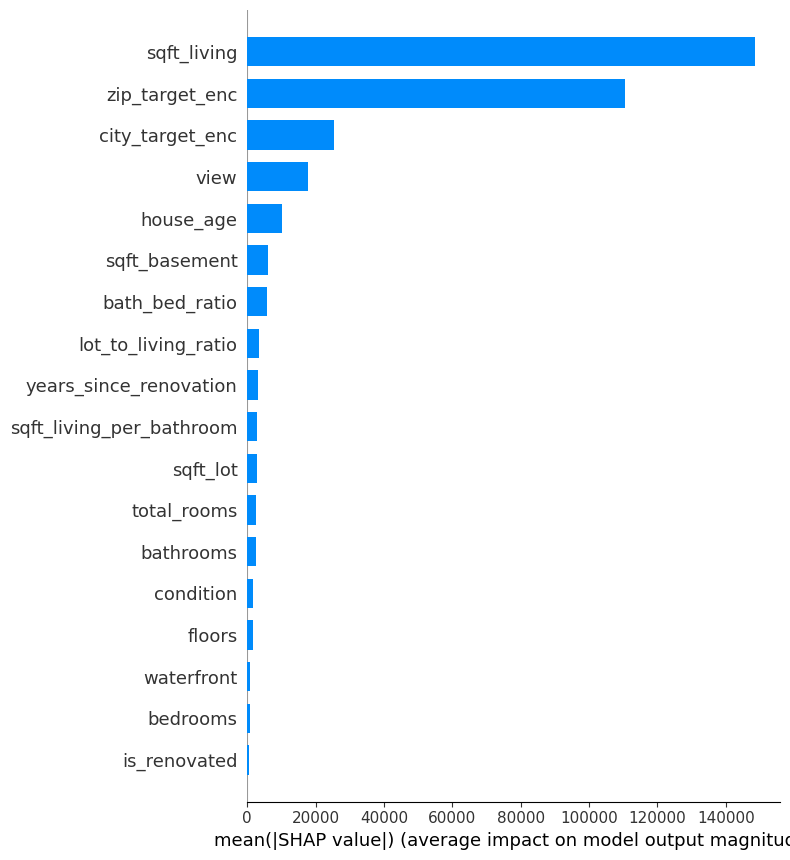

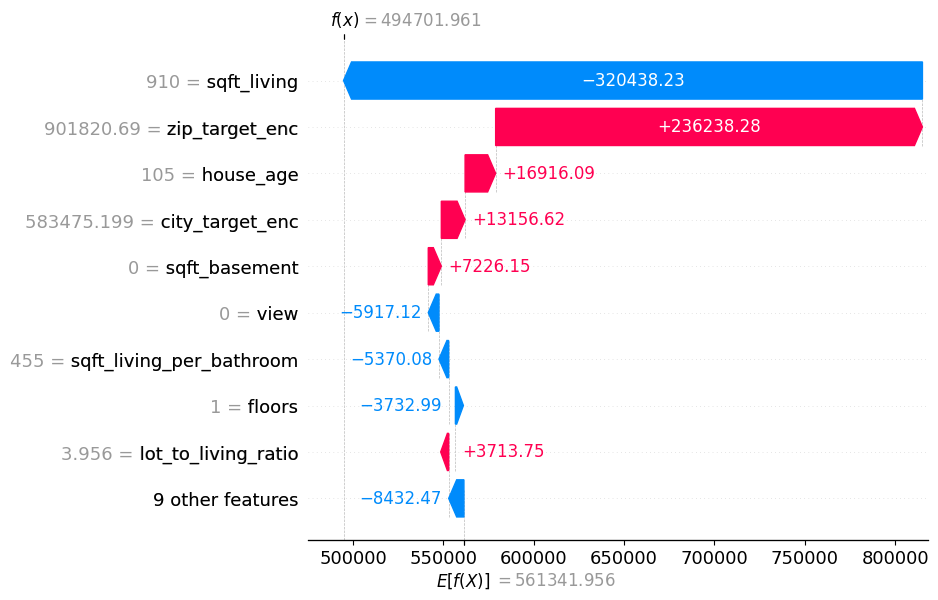

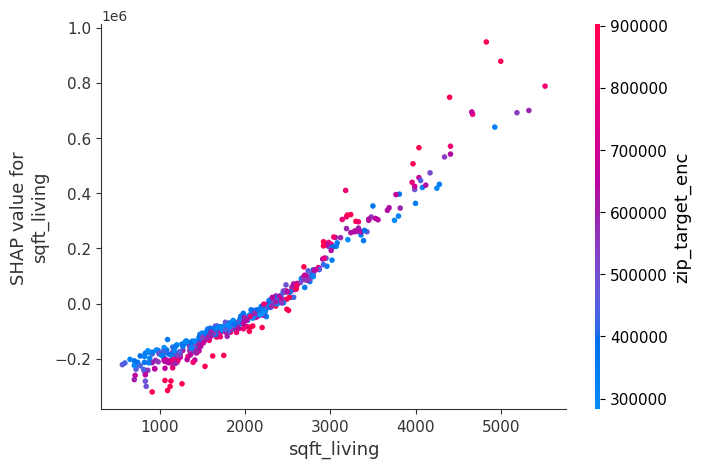

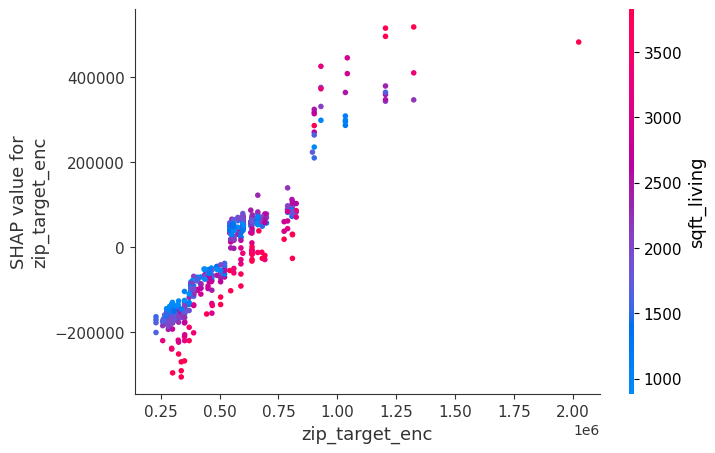

In [11]:
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Rebuild model final (biar konsisten sama X_train yang dipake SHAP)
X = pd.read_csv('house_features_v3.csv')
y = df_fe['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_rf = RandomForestRegressor(
    n_estimators=300, min_samples_split=5, min_samples_leaf=4,
    max_features=None, max_depth=None, random_state=42, n_jobs=-1
)
best_rf.fit(X_train, y_train)

# Bikin explainer - TreeExplainer khusus buat model tree-based, jauh lebih cepat
explainer = shap.TreeExplainer(best_rf)

# Ambil sample buat SHAP (kalau X_test gede, ambil sample biar gak lama)
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer(X_sample)

# 1. SUMMARY PLOT - liat fitur paling berpengaruh + arah pengaruhnya (naik/turun harga)
shap.summary_plot(shap_values, X_sample, show=True)

# 2. BAR PLOT - versi simpel, cuma ranking rata-rata besarnya pengaruh
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=True)

# 3. WATERFALL PLOT - breakdown prediksi buat 1 rumah spesifik (contoh: index ke-0 di sample)
shap.plots.waterfall(shap_values[0], show=True)

# 4. DEPENDENCE PLOT - liat gimana 1 fitur spesifik (misal sqft_living) pengaruhin prediksi,
#    dan apakah ada interaksi sama fitur lain
shap.dependence_plot('sqft_living', shap_values.values, X_sample, show=True)
shap.dependence_plot('zip_target_enc', shap_values.values, X_sample, show=True)

In [14]:
import joblib
import pandas as pd
import re

# Simpan model
joblib.dump(best_rf, 'house_price_model.pkl')

# Load data & extract zip dari statezip
df_clean = pd.read_csv('house_clean.csv')
df_clean['zip'] = df_clean['statezip'].str.extract(r'(\d+)').astype(int)

# Mapping target encoding
city_mapping = df_clean.groupby('city')['price'].mean().to_dict()
zip_mapping = df_clean.groupby('zip')['price'].mean().to_dict()

joblib.dump(city_mapping, 'city_mapping.pkl')
joblib.dump(zip_mapping, 'zip_mapping.pkl')

# Simpan urutan kolom fitur & list kota
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')
joblib.dump(sorted(df_clean['city'].unique().tolist()), 'city_list.pkl')

print("Semua file tersimpan!")

Semua file tersimpan!


In [15]:
print(best_rf.get_params()['n_estimators'])
print(best_rf.get_params()['min_samples_split'])
print(best_rf.get_params()['min_samples_leaf'])

300
5
4


In [18]:
import joblib
import pandas as pd

# Feature importance dari model final
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.to_csv('feature_importance.csv', index=False)

comparison_df = pd.DataFrame([
    {'Stage': 'Baseline (default params)', 'R2': 0.5115, 'RMSE': 202997, 'MAE': 125047},
    {'Stage': '+ Target Encoding City + Tuning', 'R2': 0.6637, 'RMSE': 168439, 'MAE': 103677},
    {'Stage': '+ Zip Target Encoding + Feature Interaction + Re-tuning', 'R2': 0.7722, 'RMSE': 138630, 'MAE': 85277},
])
comparison_df.to_csv('model_comparison.csv', index=False)
print("Artifact tambahan tersimpan!")

Artifact tambahan tersimpan!
